In [1]:
import numpy as np
import pandas as pd

from utils.data_loader import load_volvo, load_optuna_val

result_path="../Results/Volvo TranAD"

In [2]:
x_train, y_train, x_test, y_test, timestamps_train, timestamps_test, df_train, df_test = load_volvo(
    "../Dataset/Processed Dataset/volvoTrain.csv",
    "../Dataset/Processed Dataset/volvoTest.csv"
)
df_train["timestamp"] = pd.to_datetime(timestamps_train, format='ISO8601')

optuna_df = load_optuna_val(df_train)

Optuna start:  2025-12-07 00:00:00.815694+00:00
Optuna end:  2025-12-10 12:43:09.072558+00:00


C:\Users\arthu\AppData\Local\Temp\ipykernel_24796\4065204130.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


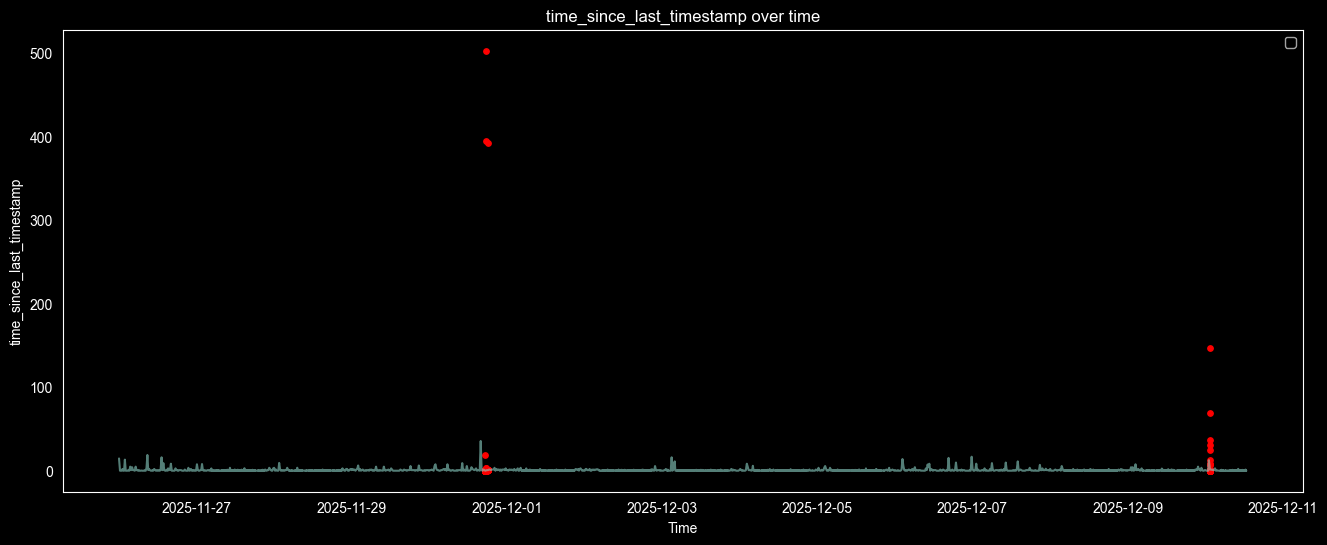

In [3]:
import numpy as np
import matplotlib.pyplot as plt

feature = "time_since_last_timestamp"
step = 1000

down_idx = np.arange(0, len(df_train), step)
anomaly_mask = df_train["label"].values == 1

plt.figure(figsize=(16,6))

plt.plot(
    df_train["timestamp"].iloc[down_idx],
    df_train[feature].iloc[down_idx],
    alpha=0.6
)

plt.scatter(
    df_train["timestamp"][anomaly_mask],
    df_train[feature][anomaly_mask],
    color="red",
    s=15
)

plt.legend()
plt.title(f"{feature} over time")
plt.xlabel("Time")
plt.ylabel(feature)
plt.grid(False)
plt.savefig("time_since_last_timestamp.png")
plt.show()

C:\Users\arthu\AppData\Local\Temp\ipykernel_24796\1738347220.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


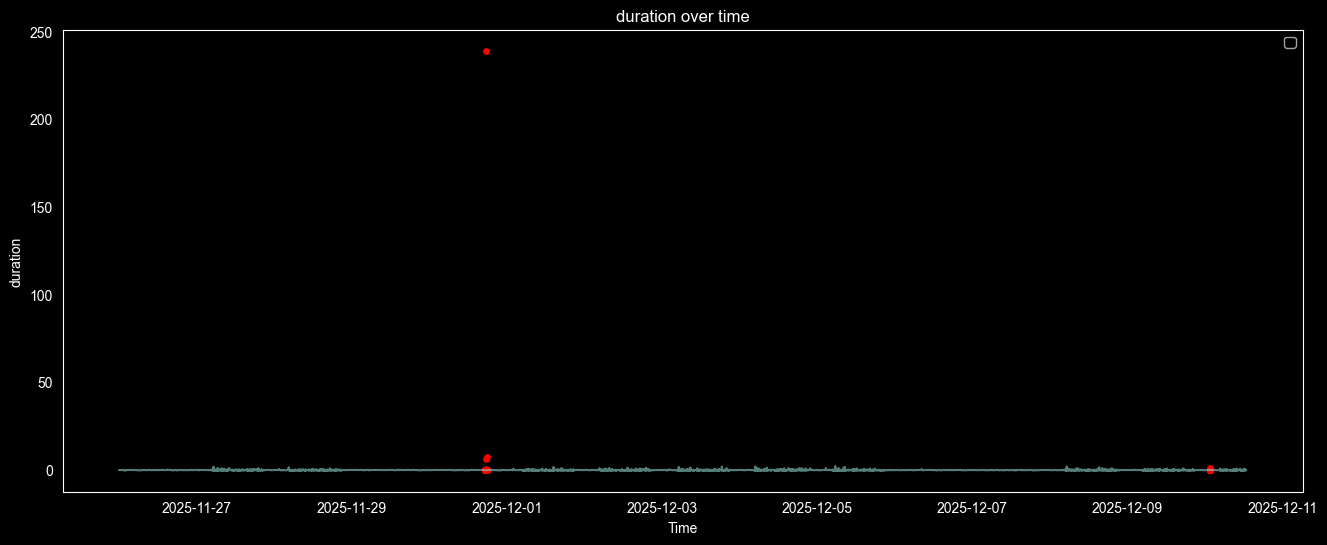

In [4]:
import numpy as np
import matplotlib.pyplot as plt

feature = "duration"
step = 1000

down_idx = np.arange(0, len(df_train), step)
anomaly_mask = df_train["label"].values == 1

plt.figure(figsize=(16,6))

plt.plot(
    df_train["timestamp"].iloc[down_idx],
    df_train[feature].iloc[down_idx],
    alpha=0.6
)

plt.scatter(
    df_train["timestamp"][anomaly_mask],
    df_train[feature][anomaly_mask],
    color="red",
    s=15
)

plt.legend()
plt.title(f"{feature} over time")
plt.xlabel("Time")
plt.ylabel(feature)
plt.grid(False)
plt.savefig("duration.png")
plt.show()

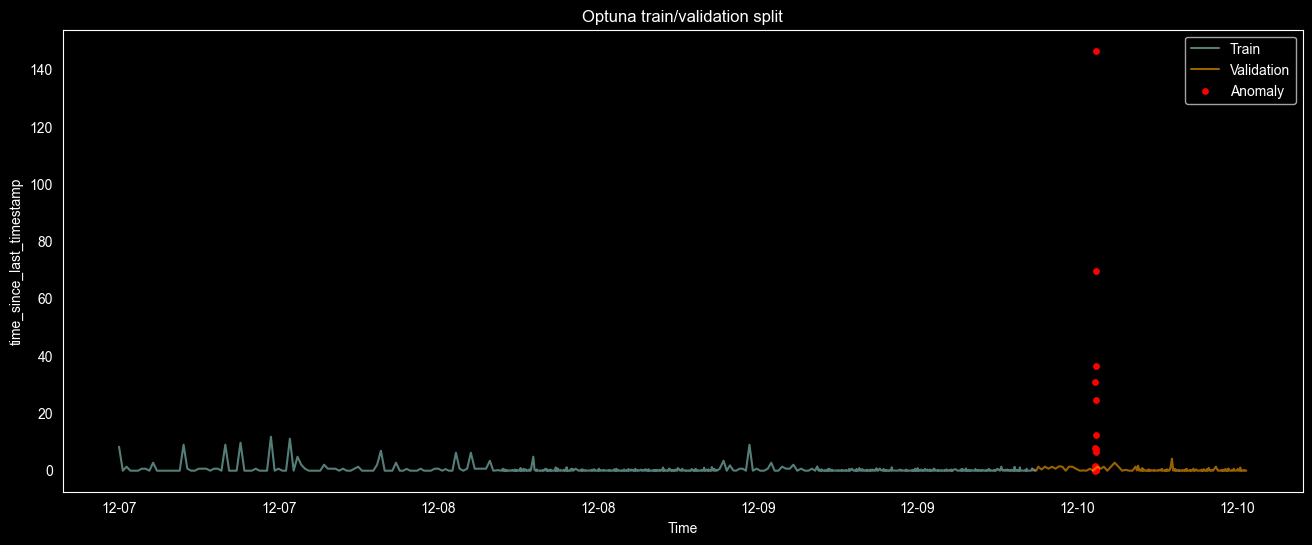

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

feature = "time_since_last_timestamp"
step = 1000

split_idx = int(len(optuna_df) * (1 - 0.2))

df_train_optuna = optuna_df.iloc[:split_idx].copy()
df_val_optuna = optuna_df.iloc[split_idx:].copy()

plt.figure(figsize=(16,6))

# -----------------------
# TRAIN (downsampled)
# -----------------------
train_idx = np.arange(0, len(df_train_optuna), step)

plt.plot(
    df_train_optuna["timestamp"].iloc[train_idx],
    df_train_optuna[feature].iloc[train_idx],
    alpha=0.6,
    label="Train"
)

# -----------------------
# VAL (downsampled)
# -----------------------
val_idx = np.arange(0, len(df_val_optuna), step)

plt.plot(
    df_val_optuna["timestamp"].iloc[val_idx],
    df_val_optuna[feature].iloc[val_idx],
    color="orange",
    alpha=0.6,
    label="Validation"
)

# -----------------------
# ANOMALIES (global but aligned)
# -----------------------
anomaly_mask_train = df_train_optuna["label"].values == 1
anomaly_mask_val = df_val_optuna["label"].values == 1

plt.scatter(
    df_train_optuna["timestamp"][anomaly_mask_train],
    df_train_optuna[feature][anomaly_mask_train],
    color="red",
    s=15,
    label="Anomaly"
)

plt.scatter(
    df_val_optuna["timestamp"][anomaly_mask_val],
    df_val_optuna[feature][anomaly_mask_val],
    color="red",
    s=15
)
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.legend()
plt.title("Optuna train/validation split")
plt.xlabel("Time")
plt.ylabel(feature)
plt.grid(False)
plt.savefig("Optuna_train_validation_split.png")
plt.show()

In [6]:
import numpy as np
import pandas as pd

df_train = df_train.copy()
df_train["timestamp"] = pd.to_datetime(df_train["timestamp"], format='ISO8601')

split1_date = "2025-12-01"
trainset_percentage = 0.8

# Fold 1 df
fold1_df = df_train[df_train['timestamp'] <= split1_date]


# Fold 2 df
fold2_df = df_train.iloc[::]

fold2_train_split_idx = int(len(fold2_df) * trainset_percentage)

fold2_train_df = fold2_df.iloc[:fold2_train_split_idx]
fold2_val_df = fold2_df.iloc[fold2_train_split_idx:]


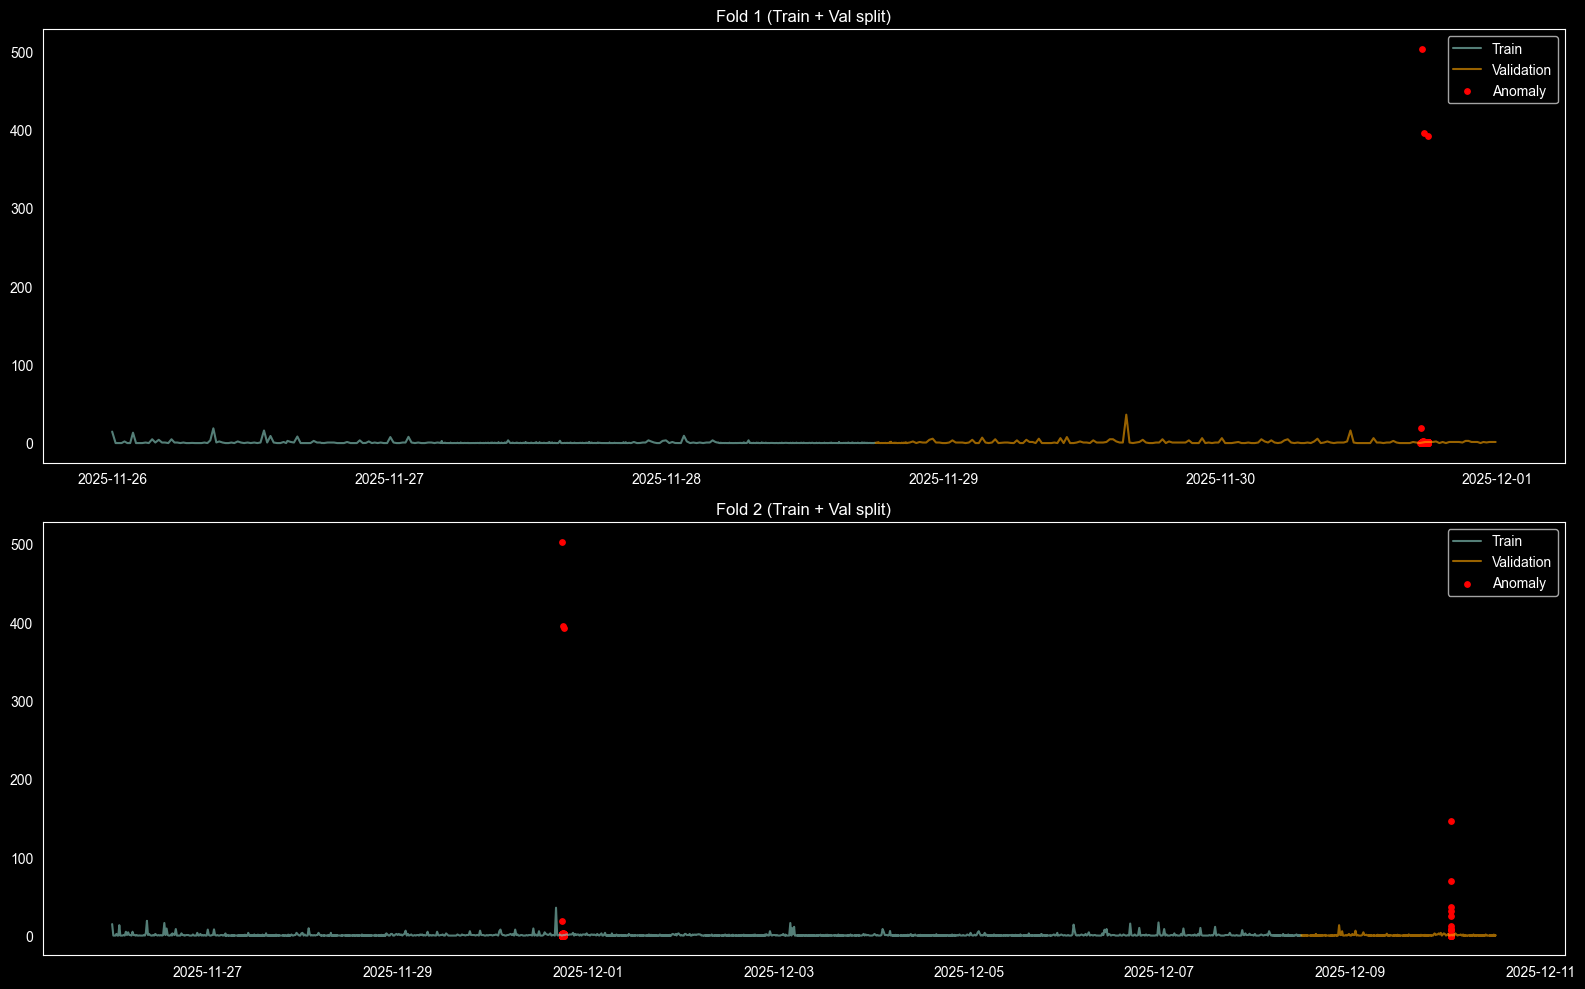

In [9]:
import matplotlib.pyplot as plt

feature = "time_since_last_timestamp"
step = 1000

# =========================================================
# Helper function for plotting a fold
# =========================================================
def plot_fold(df, title, color="blue"):

    fold_trainset_percentage = 0.8
    fold_train_split_idx = int(len(df) * fold_trainset_percentage)

    fold_train_df = df.iloc[:fold_train_split_idx].reset_index(drop=True)
    fold_val_df = df.iloc[fold_train_split_idx:].reset_index(drop=True)

    fold_train_idx = np.arange(0, len(fold_train_df), step)

    plt.plot(
        fold_train_df["timestamp"].iloc[fold_train_idx],
        fold_train_df[feature].iloc[fold_train_idx],
        alpha=0.6,
        label="Train"
    )

    fold_val_idx = np.arange(0, len(fold_val_df), step)

    plt.plot(
        fold_val_df["timestamp"].iloc[fold_val_idx],
        fold_val_df[feature].iloc[fold_val_idx],
        color="orange",
        alpha=0.6,
        label="Validation"
    )

    fold_anomaly_mask_train = fold_train_df["label"].values == 1
    fold_anomaly_mask_val = fold_val_df["label"].values == 1

    plt.scatter(
        fold_train_df["timestamp"][fold_anomaly_mask_train],
        fold_train_df[feature][fold_anomaly_mask_train],
        color="red",
        s=15,
        label="Anomaly"
    )

    plt.scatter(
        fold_val_df["timestamp"][fold_anomaly_mask_val],
        fold_val_df[feature][fold_anomaly_mask_val],
        color="red",
        s=15
    )
    plt.title(title)


plt.figure(figsize=(16,10))

plt.subplot(2,1,1)
plot_fold(fold1_df, "Fold 1 (Train + Val split)", "blue")
plt.grid(False)
plt.legend()

plt.subplot(2,1,2)
plot_fold(fold2_df, "Fold 2 (Train + Val split)", "green")
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.savefig("CV_folds.png")
plt.show()
plt.show()

In [3]:
x_train, y_train, x_test, y_test, timestamps_train, timestamps_test, df_train, df_test = load_volvo(
    "../Dataset/Processed Dataset/volvoTrain.csv",
    "../Dataset/Processed Dataset/volvoTest.csv"
)
df_optuna = load_optuna_val(df_train)
print (len(df_optuna))

Optuna start:  2025-12-07 00:00:00.815694+00:00
Optuna end:  2025-12-10 12:43:09.072558+00:00
1435500
